# Binary Classification: Breast Cancer (Malignant vs Benign)

The **Breast Cancer Wisconsin dataset** contains 569 samples of fine needle aspirates (FNA) of breast masses, with 30 numerical features computed from digitized images. The goal is to predict whether a tumor is **malignant** (cancerous) or **benign** (non-cancerous).

We will:
1. Load & explore the data
2. Split into train/test sets
3. Train three different classifiers
4. Evaluate and compare performance
5. (Bonus) Cross-validation, feature scaling, decision boundary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully")

All libraries imported successfully


---
## Part 1: Load and Explore the Data

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Class distribution:", np.bincount(y))
print("Class 0 = malignant, Class 1 = benign")

Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Class distribution: [212 357]
Class 0 = malignant, Class 1 = benign


In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = data.target_names[y]
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [4]:
df.iloc[:, :30].describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

Train size: 455 samples
Test size:  114 samples
Train class distribution: [170 285]
Test class distribution:  [42 72]


---
## Part 2: Train Classifiers

### 2.1 Logistic Regression

In [7]:
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("First 20 predictions:", y_pred_lr[:20])
print("First 20 actual:     ", y_test[:20])

First 20 predictions: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]
First 20 actual:      [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


### 2.2 K-Nearest Neighbors

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("First 20 predictions:", y_pred_knn[:20])
print("First 20 actual:     ", y_test[:20])

First 20 predictions: [0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]
First 20 actual:      [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


### 2.3 Gaussian Naive Bayes

In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("First 20 predictions:", y_pred_gnb[:20])
print("First 20 actual:     ", y_test[:20])

First 20 predictions: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]
First 20 actual:      [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


---
## Part 3: Model Evaluation

### 3.1 Logistic Regression Evaluation

In [10]:
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.9649


In [11]:
print(classification_report(y_test, y_pred_lr, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



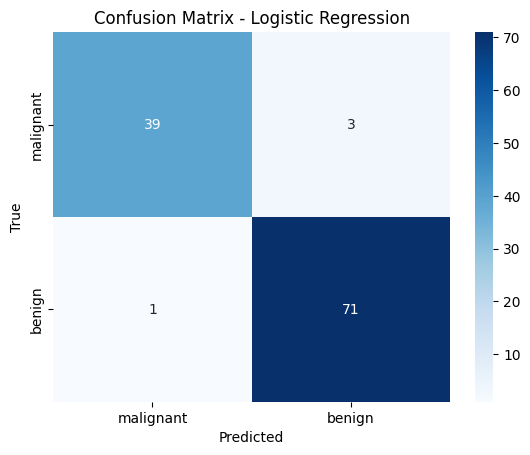

In [12]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

### 3.2 KNN Evaluation

In [13]:
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}")

KNN Accuracy: 0.9123


In [14]:
print(classification_report(y_test, y_pred_knn, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



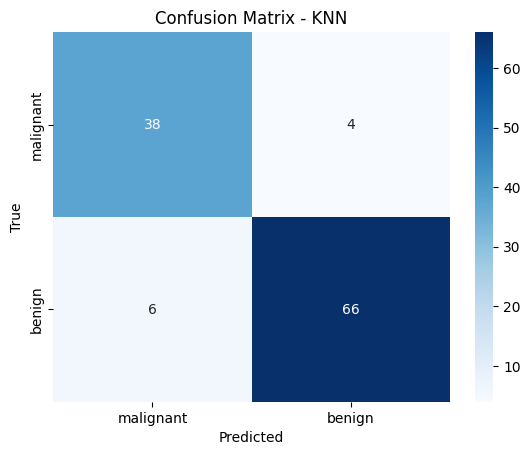

In [15]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix - KNN')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

### 3.3 Gaussian Naive Bayes Evaluation

In [16]:
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"GaussianNB Accuracy: {acc_gnb:.4f}")

GaussianNB Accuracy: 0.9386


In [17]:
print(classification_report(y_test, y_pred_gnb, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



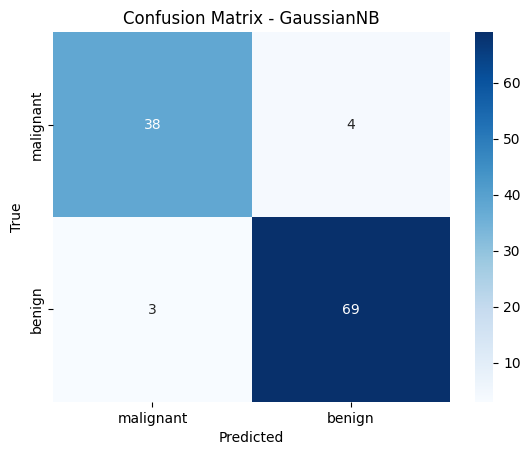

In [18]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix - GaussianNB')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

---
## Part 4: Comparison and Analysis

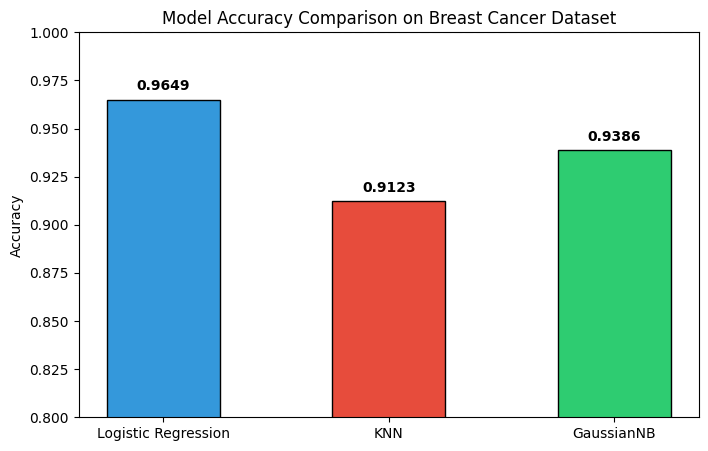

In [19]:
models = ['Logistic Regression', 'KNN', 'GaussianNB']
accuracies = [acc_lr, acc_knn, acc_gnb]

plt.figure(figsize=(8, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = plt.bar(models, accuracies, color=colors, width=0.5, edgecolor='black')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison on Breast Cancer Dataset')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.show()

**Written Analysis:**

1. **Which model performed best?**
   Logistic Regression achieved the highest accuracy (0.9649), followed by GaussianNB (0.9386) and KNN (0.9123). LR also had the best precision and recall for both classes.

2. **Did different models make different types of errors?**
   Yes. LR made 3 false positives (predicting malignant as benign) and 1 false negative (benign as malignant). KNN made 4 false positives and 6 false negatives. GNB made 4 false positives and 3 false negatives. KNN had more false negatives, which is worse for cancer detection.

3. **For this dataset, which classifier seems more suitable and why?**
   Logistic Regression is most suitable. It has the highest accuracy and balanced precision/recall. It also benefits significantly from scaling (accuracy improved to 0.9825). Its interpretability (coefficient weights) is valuable for medical diagnosis.

---
## Bonus (Optional)

### B1: Cross-Validation

In [20]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'KNN': KNeighborsClassifier(),
    'GaussianNB': GaussianNB()
}
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    print(f"{name:25s} -> Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression       -> Accuracy: 0.9508 (+/- 0.0180)
KNN                       -> Accuracy: 0.9279 (+/- 0.0218)
GaussianNB                -> Accuracy: 0.9385 (+/- 0.0146)


### B2: Feature Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")
print("Scaled mean (first 5):", X_train_scaled.mean(axis=0).round(2)[:5])
print("Scaled std (first 5): ", X_train_scaled.std(axis=0).round(2)[:5])

log_reg_scaled = LogisticRegression(max_iter=5000)
log_reg_scaled.fit(X_train_scaled, y_train)
y_pred_lr_scaled = log_reg_scaled.predict(X_test_scaled)
acc_lr_scaled = accuracy_score(y_test, y_pred_lr_scaled)
print(f"LR Accuracy (unscaled): {acc_lr:.4f} -> (scaled): {acc_lr_scaled:.4f}")

knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)
y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)
acc_knn_scaled = accuracy_score(y_test, y_pred_knn_scaled)
print(f"KNN Accuracy (unscaled): {acc_knn:.4f} -> (scaled): {acc_knn_scaled:.4f}")

Scaling complete!
Scaled mean (first 5): [-0.  0. -0.  0.  0.]
Scaled std (first 5):  [1. 1. 1. 1. 1.]
LR Accuracy (unscaled): 0.9649 -> (scaled): 0.9825
KNN Accuracy (unscaled): 0.9123 -> (scaled): 0.9561


---
## Summary

| Task | Class / Function |
|---|---|
| Load dataset | `sklearn.datasets.load_breast_cancer()` |
| Train/test split | `train_test_split()` |
| Logistic Regression | `LogisticRegression()` |
| K-Nearest Neighbors | `KNeighborsClassifier()` |
| Gaussian Naive Bayes | `GaussianNB()` |
| Evaluation | `accuracy_score()`, `classification_report()`, `confusion_matrix()` |
| Cross-validation | `cross_val_score()` |
| Feature scaling | `StandardScaler()` |